# FilPHANGS - CSV Processing & Galaxy Statistics

Loads per-galaxy filament CSV outputs from the FilPHANGS pipeline and produces:
- **KDE distributions** of length, mass, line density, surface density, and curvature
- **Region-sorted breakdowns** (bar / spiral / interarm / centre / disc)
- **Property vs galaxy-property** correlation grids (3x3 panels per scale)
- **Filament mass vs SFR** scatter plots for multiple scale combinations

**Toggle**: set `sr = False` for normal per-galaxy summaries, `sr = True` to break
each galaxy into morphological regions (requires `masks_v5_simple` region files).

**Run order**: Cell 1 (utilities) -> Cell 2 (load data) -> Cells 3-5 (figures)


In [13]:
# =============================================================================
# Cell 1: Imports and shared utilities
# Run this cell first -- it defines all functions used by later cells.
# Edit the PATH constants below to match your environment.
# =============================================================================
import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.wcs import FITSFixedWarning
from reproject import reproject_interp
from scipy.stats import pearsonr

warnings.filterwarnings('ignore', category=FITSFixedWarning)

# -- Scale -> colour mapping. Edit here to change the palette globally. -------
SCALE_COLORS = {
    "16":  "#e41a1c",   # red
    "32":  "#ff7f00",   # orange
    "64":  "#4daf4a",   # green
    "128": "#377eb8",   # blue
    "256": "#984ea3",   # purple
}

# -- PHANGS morphological region integer labels (masks_v5) --------------------
REGION_NAMES = {
    1:"center", 2:"bar", 3:"bar", 4:"interarm",
    5:"spiral", 6:"spiral", 7:"interarm", 8:"interarm",
    9:"disc", 10:"disc",
}

QUANTITIES = ["length", "mass", "density", "surface_density", "curvature"]
XLIMS   = {"length":(1,5), "mass":(2,8), "density":(0,5),
           "curvature":(0,2), "surface_density":(-4,4.5)}
XLABELS = {"length":"log(pc)", "mass":"log(M_sun)", "density":"log(M_sun/pc)",
           "curvature":"Radians", "surface_density":"log(M_sun/pc^2)"}

# -- Paths: edit once here; all cells use these constants ---------------------
BASE_DIR    = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
CSV_PATH    = BASE_DIR / "ImageData.xlsx"
REGION_DIR  = BASE_DIR / "masks_v5_simple"
ORIG_IMAGES = BASE_DIR / "OriginalImages"
OUTPUT_DIR  = BASE_DIR / "Figures"
OUTPUT_DIR.mkdir(exist_ok=True)

# -- SFR values from Chandar et al. 2025 Table 1 (M_sun/yr) ------------------
SFR_TABLE = {
    "ngc0628":0.93, "ngc1087":1.25, "ngc1300":1.02, "ngc1365":12.88,
    "ngc1385":1.96, "ngc1433":0.56, "ngc1512":0.59, "ngc1566":3.21,
    "ngc1672":6.60, "ngc2835":0.57, "ngc3351":0.87, "ngc3627":3.31,
    "ngc4254":2.77, "ngc4303":4.25, "ngc4321":2.43, "ngc4535":1.23,
    "ngc5068":0.20, "ngc7496":2.00,
}

# =============================================================================
# Data utilities
# =============================================================================

def getInfo(label, csv_path=CSV_PATH):
    """Read galaxy metadata (distance, pixscale, etc.) from the Excel catalogue."""
    table = pd.read_excel(csv_path)
    parts = label.rsplit("_", 1)
    if len(parts) < 2: return None
    label_name, band = parts
    mask = ((table["label"].str.strip().str.lower() == label_name.lower()) &
            (table["Band"].str.strip().str.lower()  == band.lower()))
    row = table[mask]
    if row.empty: return None
    r = row.iloc[0]
    return (r["current_dist"], r["res"], r["pixscale"], np.nan,
            r["Band"], r["Power of 2 min"], r["Power of 2 max"], bool(r["Rem_sources"]))

def getScale(filename):
    """Extract the CDD scale string ('16','32',...,'256') from a filename."""
    for s in ("256","128","64","32","16"):
        if s in str(filename): return s
    return None

def getRegionData(galaxy_label, orig_data, orig_header):
    """Reproject the PHANGS region mask into the pixel frame of orig_data."""
    galaxy = galaxy_label.split("_")[0]
    for fname in os.listdir(REGION_DIR):
        if galaxy.lower() in fname.lower() and fname.lower().endswith((".fits",".fit",".fz")):
            with fits.open(REGION_DIR / fname, ignore_missing=True) as h:
                rdata, rhdr = np.array(h[0].data), h[0].header
            rep, _ = reproject_interp((rdata, rhdr), orig_header, shape_out=orig_data.shape)
            return np.nan_to_num(rep, nan=0.0)
    print(f"  No region file found for {galaxy}")
    return np.full(orig_data.shape, np.nan)

def getSurfaceDensityByRegion(galaxy_name, region_val, scale):
    """Return pixel-level surface density (M_sun/pc^2) for one region and scale."""
    mol_dir  = BASE_DIR / galaxy_name / "Molecular_Mass"
    info     = getInfo(galaxy_name)
    if info is None or not mol_dir.is_dir(): return np.array([])
    ScalePix = info[2] * 4.848 * info[0]   # parsecs per pixel
    for fname in os.listdir(mol_dir):
        fpath = mol_dir / fname
        if fpath.suffix.lower() not in (".fits",".fit",".fz"): continue
        if scale not in fname: continue
        try:
            with fits.open(fpath, ignore_missing=True) as h:
                orig_data, orig_hdr = np.array(h[0].data), h[0].header
            region_map = getRegionData(galaxy_name, orig_data, orig_hdr)
            pixels = orig_data[region_map == region_val].flatten()
            bf = int(scale) / 16
            return pixels / ((bf * ScalePix) ** 2)
        except Exception as e:
            print(f"  SurfDens error ({galaxy_name},{scale}pc): {e}")
    return np.array([])

def get_sfr(galaxy_name):
    """Return log10(SFR) from the hardcoded Chandar+2025 table."""
    key = galaxy_name.replace("_F770W","").strip().lower()
    if key in SFR_TABLE: return np.log10(SFR_TABLE[key])
    raise KeyError(f"'{galaxy_name}' not in SFR_TABLE")

def safe_log_arr(arr):
    """log10(arr) returning NaN for non-positive values."""
    a = np.array(arr, dtype=float)
    out = np.full_like(a, np.nan)
    m = np.isfinite(a) & (a > 0)
    out[m] = np.log10(a[m])
    return out

def stats_log(arr):
    """Return (median, p16, p84) of log10(arr), ignoring NaN."""
    v = safe_log_arr(arr)
    v = v[np.isfinite(v)]
    return (np.median(v), np.percentile(v,16), np.percentile(v,84)) if len(v) else (np.nan,)*3

def pearson_with_err(x, y):
    """Pearson r with 1-sigma uncertainty via Fisher Z transform."""
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 4: return np.nan, np.nan
    r, _ = pearsonr(x, y)
    se = 1.0 / np.sqrt(len(x) - 3)
    return r, (np.tanh(np.arctanh(r)+se) - np.tanh(np.arctanh(r)-se)) / 2

# =============================================================================
# Plotting helpers
# =============================================================================

def _legend_handles():
    """Return Line2D handles for the scale-colour legend."""
    return [Line2D([0],[0], color=SCALE_COLORS[s], lw=3)
            for s in sorted(SCALE_COLORS, key=float)]

def plot_quantity(data_dict, quantity, ax, region=-1):
    """
    KDE of `quantity` across all available scales, drawn on axes `ax`.
    data_dict: {scale_str: array_of_values}
    region: integer region label (-1 = no region label in title)
    Returns the total filament count across all scales.
    """
    num_fils = 0
    for s in sorted(data_dict, key=float):
        arr = np.array(data_dict[s])
        num_fils += len(arr)
        if not len(arr): continue
        vals = arr if quantity == "curvature" else np.log10(arr[arr > 0])
        if not len(vals): continue
        sns.kdeplot(vals, label=f"{s} pc", lw=2, color=SCALE_COLORS.get(s), ax=ax)
    ax.set_xlabel(XLABELS[quantity])
    ax.set_ylabel("Density")
    ax.set_xlim(XLIMS[quantity])
    ax.grid(True, ls="--", alpha=0.6)
    if region != -1:
        ax.set_title(f"{quantity.capitalize()} - {REGION_NAMES.get(int(region), region)}")
    else:
        ax.set_title(f"{quantity.capitalize()}")
    return num_fils

def plot_galaxy_image(galaxy_name, ax, fits_folder=ORIG_IMAGES, n_total=None):
    """Show the original FITS image for galaxy_name in ax (used as the rightmost column)."""
    title = galaxy_name if n_total is None else f"{galaxy_name}\nN={n_total}"
    for fname in os.listdir(fits_folder):
        if fname.endswith(".fits") and galaxy_name.lower() in fname.lower():
            with fits.open(fits_folder / fname) as h:
                img = np.nan_to_num(h[0].data)
            ax.imshow(np.clip(img, *np.percentile(img, [2,98])),
                      cmap="viridis", origin="lower", vmin=0, vmax=20)
            ax.set_title(title, fontsize=9)
            ax.axis("off")
            return
    ax.set_title(f"{galaxy_name} (image missing)" if n_total is None
                 else f"{galaxy_name} (image missing)\nN={n_total}")
    ax.axis("off")

def get_rows(galaxy_subset, galaxy_data):
    """
    Count the total number of region rows that plot_galaxies_subset will generate.
    A region is counted if it contains >= 10 filaments at any single scale.
    Must match the logic in plot_galaxies_subset exactly so gridspec is sized correctly.
    """
    total = 0
    for gal in galaxy_subset:
        valid = set()
        for arr in galaxy_data[gal]["region"].values():
            vals, cnts = np.unique(arr, return_counts=True)
            valid |= {v for v,c in zip(vals,cnts) if c >= 10}
        total += len(valid)
    return total

def plot_galaxies_subset(galaxy_subset, filename, fits_folder, galaxy_data, output_folder,
                         sort_region=False, write=True):
    """
    Generate a summary figure for a subset of galaxies.

    Each galaxy occupies one row (or one row per region when sort_region=True).
    Columns: Length | Mass | Line Density | Surface Density | Curvature | Galaxy Image

    Parameters
    ----------
    galaxy_subset : list of galaxy folder names to include
    filename      : output filename (PNG and PDF are both saved)
    fits_folder   : directory containing original FITS images
    galaxy_data   : dict produced by Cell 2
    output_folder : directory where figures are saved
    sort_region   : if True, expand each galaxy into one row per morphological region
    write         : if False, only display (do not save)
    """
    n_rows = (sum(get_rows([g], galaxy_data) for g in galaxy_subset)
              if sort_region else len(galaxy_subset))

    fig = plt.figure(figsize=(25, 4.8*n_rows + 0.8))
    gs  = gridspec.GridSpec(n_rows+1, 6, figure=fig,
                            height_ratios=[0.25]+[1]*n_rows)

    # Shared legend row at the top
    leg_ax = fig.add_subplot(gs[0, :])
    leg_ax.axis("off")
    leg_ax.legend(_legend_handles(),
                  [f"{s} pc" for s in sorted(SCALE_COLORS, key=float)],
                  loc="center", ncol=len(SCALE_COLORS), fontsize=13, frameon=False)

    row = 1
    for gal in galaxy_subset:
        d = galaxy_data[gal]
        if sort_region:
            # Build per-region filtered data dicts across all scales
            rdicts = {}
            for scale, reg_arr in sorted(d["region"].items(), key=lambda x: float(x[0])):
                vals, cnts = np.unique(reg_arr, return_counts=True)
                for rv in (v for v,c in zip(vals,cnts) if c >= 10):
                    m = reg_arr == rv
                    r = rdicts.setdefault(rv, {q:{} for q in QUANTITIES})
                    r["length"][scale]  = d["length"].get(scale, np.array([]))[m].tolist()
                    r["mass"][scale]    = d["mass"].get(scale, np.array([]))[m].tolist()
                    r["density"][scale] = d["density"].get(scale, np.array([]))[m].tolist()
                    cur = d["curvature"].get(scale, np.array([]))
                    r["curvature"][scale]       = [b for a,b in zip(reg_arr[:len(cur)], cur) if a==rv]
                    r["surface_density"][scale] = getSurfaceDensityByRegion(gal, rv, scale).tolist()
            for j, (rv, qd) in enumerate(rdicts.items()):
                axs = [fig.add_subplot(gs[row+j, c]) for c in range(6)]
                n_total = None
                for ax, q in zip(axs, QUANTITIES):
                    n = plot_quantity(qd[q], q, ax, region=rv)
                    if q == "length":
                        n_total = n
                plot_galaxy_image(gal, axs[5], fits_folder, n_total=n_total)
                label = (f"{gal}\n" if j == 0 else "") + "Density"
                axs[0].set_ylabel(label, rotation=90, size="large")
            row += len(rdicts)
        else:
            axs = [fig.add_subplot(gs[row, c]) for c in range(6)]
            n_total = None
            for ax, q in zip(axs, QUANTITIES):
                n = plot_quantity(d[q], q, ax)
                if q == "length":
                    n_total = n
            plot_galaxy_image(gal, axs[5], fits_folder, n_total=n_total)
            axs[0].set_ylabel(f"{gal}\nDensity", rotation=90, size="large")
            row += 1

    plt.tight_layout()
    fig.subplots_adjust(top=0.97)
    if write:
        output_folder = Path(output_folder)
        for ext in (".png", ".pdf"):
            fig.savefig(output_folder / (Path(filename).stem + ext),
                        dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


In [ ]:
# ------------------------------------------------------------
sr = False
# ------------------------------------------------------------

base_dir      = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
csv_path      = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\ImageData.xlsx")
fits_folder   = base_dir / "OriginalImages"
output_folder = base_dir / "Figures"
output_folder.mkdir(exist_ok=True)
Galaxies_per_figure = 6

galaxy_folders = [
    folder for folder in os.listdir(base_dir)
    if (base_dir / folder).is_dir()
    and folder not in {'Figures', 'OriginalImages', 'masks_v5_simple', 'IC5146_PSW'}
    and not folder.endswith(('.txt', '.xlsx'))
    and 'F770W' in folder
]

valid_galaxies = []
galaxy_data    = {}

for folder in galaxy_folders:
    galaxy_name      = folder
    synthetic_folder = base_dir / folder / 'SyntheticMap'

    if not synthetic_folder.is_dir():
        print(f"Skipping {galaxy_name}: SyntheticMap directory not found")
        continue

    # getInfo needed for BF correction and surface density.
    # Each blocked skeleton pixel contains the integrated 2D Gaussian flux
    # (flux_fit = data * sqrt(2pi) * sigma_blocked). sigma is in blocked-pixel units,
    # so the PSF footprint area scales as BF^2 physically. The pipeline assigns the same
    # numerical flux_fit to all scales, underestimating the per-pixel mass by BF^2 at
    # larger scales. With BF fewer skeleton pixels (1D reduction), the CSV mass total is
    # underestimated by BF^2. Multiply by BF^2 to recover the correct mass.
    info = getInfo(galaxy_name, csv_path)
    if info is None:
        print(f"  {galaxy_name}: not in catalogue, skipping")
        continue
    distance_Mpc, _, pixscale, _, _, min_power, max_power, _ = info
    ScalePix = pixscale * 4.848 * distance_Mpc   # pc per native pixel

    mass_dict = {}; length_dict = {}; density_dict = {}
    region_dict = {}; curvature_dict = {}; mass_surface = {}
    pixel_regions = []

    try:
        for file in os.listdir(synthetic_folder):
            if file.endswith(".fits"):
                continue

            file_path = synthetic_folder / file
            try:
                if file.endswith(".xlsx"):
                    df = pd.read_excel(file_path, engine='openpyxl')
                elif file.endswith(".xls"):
                    df = pd.read_excel(file_path)
                elif file.endswith(".csv"):
                    df = pd.read_csv(file_path)
                else:
                    continue
            except Exception as e:
                print(f"  {galaxy_name}: could not read {file} -- {e}")
                continue

            scale = getScale(str(file_path))
            if scale is None:
                print(f"  {galaxy_name}: could not extract scale from {file}")
                continue

            required_cols = [f"Regions_{scale}.0", f"Mass_{scale}.0",
                             f"Line_Density_{scale}.0", f"Length_{scale}.0",
                             f"Curvature_{scale}.0"]
            missing = [c for c in required_cols if c not in df.columns]
            if missing:
                print(f"  {galaxy_name}/{file}: missing columns {missing}, available: "
                      f"{[c for c in df.columns if scale in c]}")
                continue

            # BF = 2^rank where rank is this scale's position in the galaxy's sorted scale list.
            scale_int = int(scale)
            rank = int(round(np.log2(scale_int))) - int(min_power)
            BF = max(1, 2 ** rank)

            try:
                mass_dict[scale]    = np.array(df[f'Mass_{scale}.0'])    * BF**2
                length_dict[scale]  = np.array(df[f'Length_{scale}.0'])
                density_dict[scale] = np.array(df[f'Line_Density_{scale}.0']) * BF**2
                region_dict[scale]  = np.array(df[f'Regions_{scale}.0'])

                curvature_values = []
                for i, s in enumerate(df[f'Curvature_{scale}.0']):
                    if pd.isna(s):
                        continue
                    try:
                        if isinstance(s, (int, float, np.number)):
                            curvature_values.append(float(s))
                        elif isinstance(s, str):
                            curvature_values.append(float(s.split()[0]))
                        else:
                            print(f"  Unexpected curvature type at index {i}: {type(s)}")
                    except (ValueError, AttributeError) as e:
                        print(f"  Curvature parse error at index {i}: {s} -- {e}")
                curvature_dict[scale] = np.array(curvature_values)

            except (KeyError, ValueError) as e:
                print(f"  Column read error for {galaxy_name}: {e}")
                continue

            if not sr:
                surface_density_path = base_dir / folder / 'Molecular_Mass'
                if not surface_density_path.is_dir():
                    continue

                for fname in os.listdir(surface_density_path):
                    fpath = surface_density_path / fname
                    if fpath.suffix.lower() not in (".fits", ".fit", ".fz"):
                        continue
                    mol_scale = getScale(str(fpath))
                    if mol_scale is None:
                        continue
                    try:
                        with fits.open(fpath, ignore_missing=True) as hdul:
                            if hdul[0].data is None:
                                print(f"  No data in primary HDU: {fname}")
                                continue
                            OrigData = np.array(hdul[0].data)
                        bf = int(mol_scale) / 16
                        mass_surface[mol_scale] = OrigData.flatten() / ((bf * ScalePix) ** 2)
                    except Exception as e:
                        print(f"  Surface density error ({galaxy_name}, {mol_scale}pc): {e}")

        if length_dict:
            valid_galaxies.append(galaxy_name)
            galaxy_data[galaxy_name] = {
                "mass":            mass_dict,
                "length":          length_dict,
                "density":         density_dict,
                "region":          region_dict,
                "curvature":       curvature_dict,
                "surface_density": mass_surface,
                "pixel_regions":   pixel_regions,
            }
        else:
            print(f"  {galaxy_name}: no valid scale data found in SyntheticMap")

    except Exception as e:
        print(f"Error loading {galaxy_name}: {e}")

plot_galaxies_subset(valid_galaxies[:Galaxies_per_figure],
                     "First6Galaxies_Summary.png", fits_folder, galaxy_data, output_folder, sort_region=sr)
plot_galaxies_subset(valid_galaxies[Galaxies_per_figure:2*Galaxies_per_figure],
                     "Middle6Galaxies_Summary.png", fits_folder, galaxy_data, output_folder, sort_region=sr)
plot_galaxies_subset(valid_galaxies[2*Galaxies_per_figure:],
                     "Last6Galaxies_Summary.png", fits_folder, galaxy_data, output_folder, sort_region=sr)
print("Loaded galaxies:", valid_galaxies)


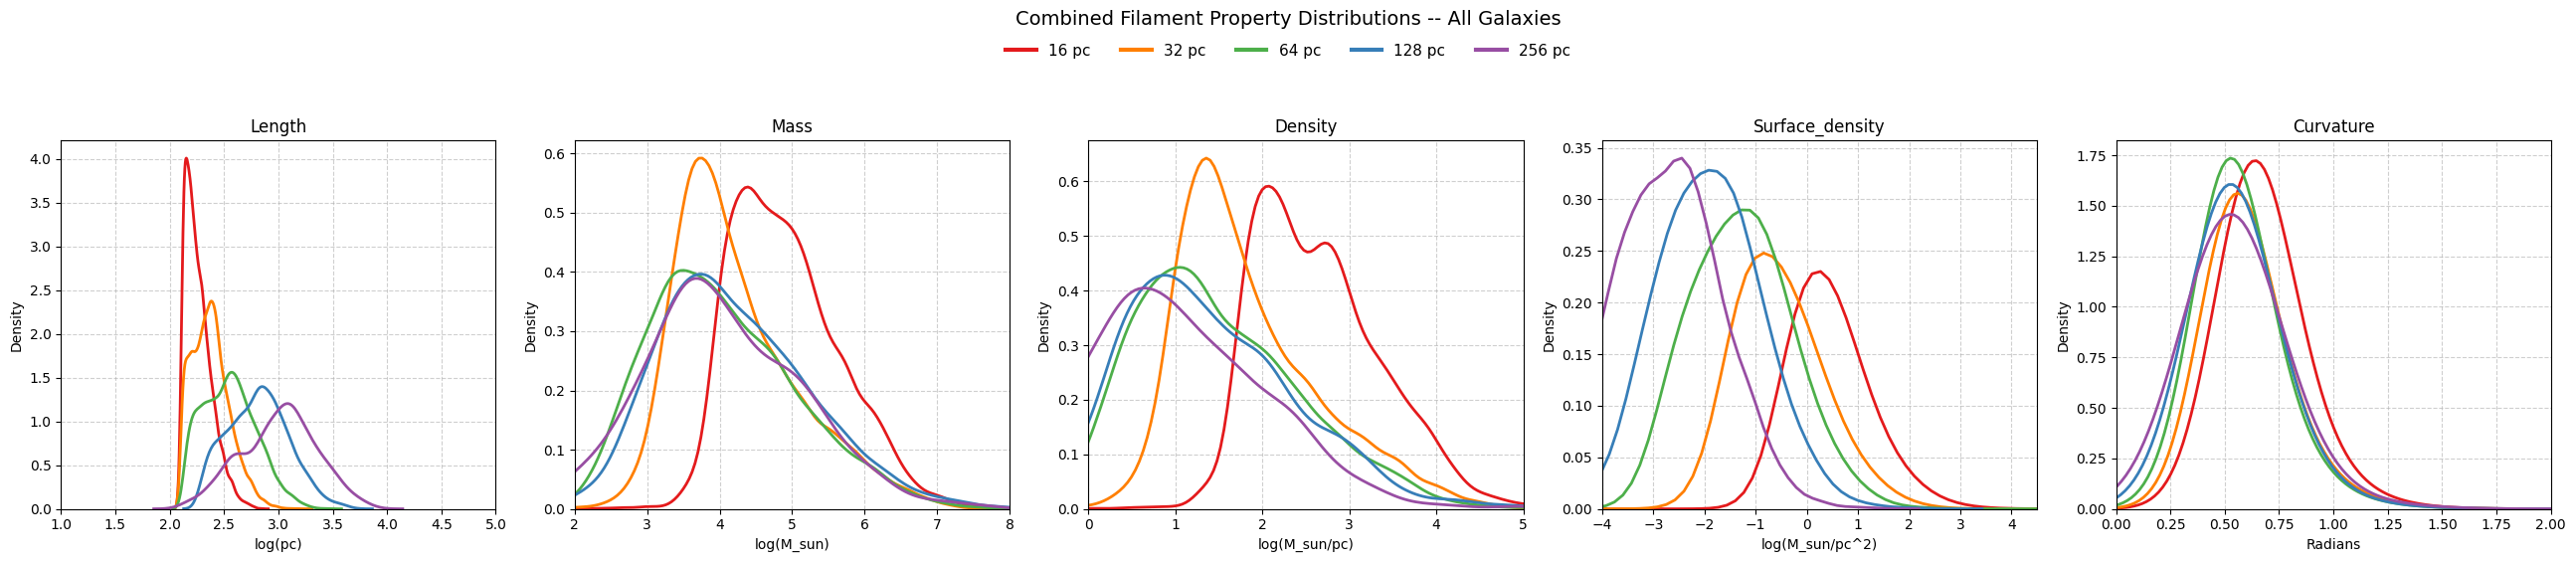

In [15]:
# =============================================================================
# Cell 3: Combined KDE Distributions -- All Galaxies
# Pools filament measurements from every galaxy into one sample per scale and
# plots the combined KDE. Gives a population-level view of each property.
# =============================================================================
SCALES = list(SCALE_COLORS.keys())
master = {q: {s: [] for s in SCALES} for q in QUANTITIES}

for gal in valid_galaxies:
    for s in SCALES:
        for q in QUANTITIES:
            arr = galaxy_data[gal][q].get(s)
            if arr is not None and len(arr):
                master[q][s].append(arr)

# Flatten lists of arrays into single arrays
for q in master:
    for s in master[q]:
        master[q][s] = np.concatenate(master[q][s]) if master[q][s] else np.array([])

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for ax, q in zip(axes, QUANTITIES):
    plot_quantity(master[q], q, ax)

fig.legend(_legend_handles(),
           [f"{s} pc" for s in sorted(SCALE_COLORS, key=float)],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=5, fontsize=11, frameon=False)
fig.suptitle("Combined Filament Property Distributions -- All Galaxies", fontsize=14, y=1.12)
plt.tight_layout()
for ext in (".png", ".pdf"):
    fig.savefig(OUTPUT_DIR / f"AllGalaxies_Combined{ext}", dpi=300, bbox_inches="tight")
plt.show()


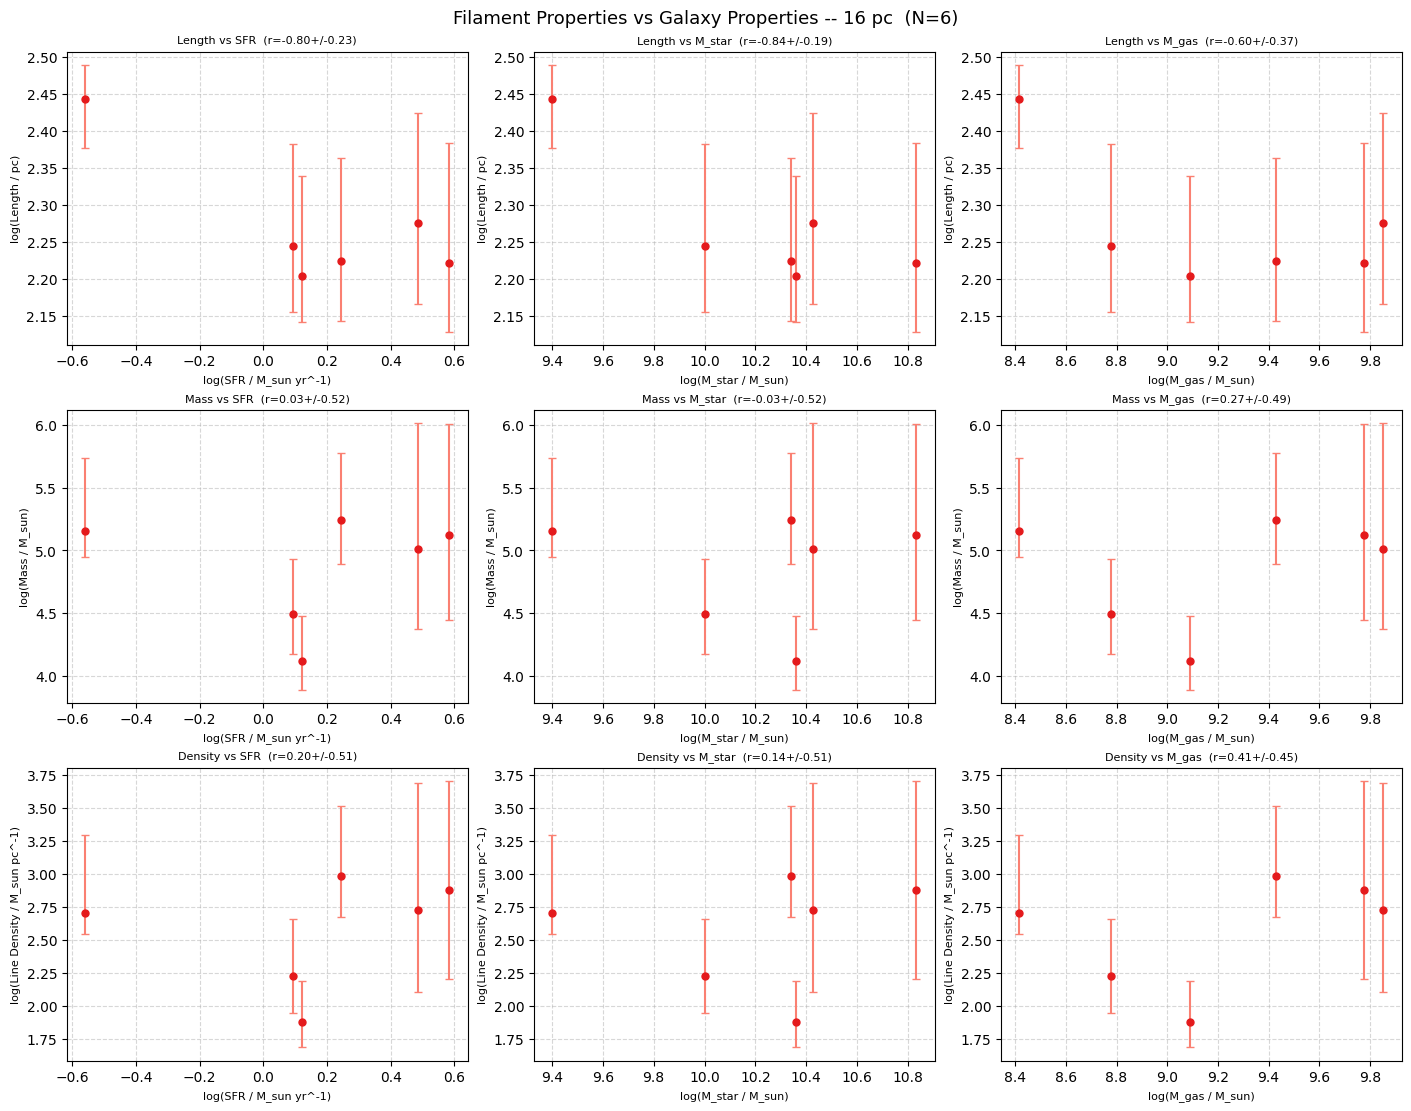

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\Correlations_16pc.png


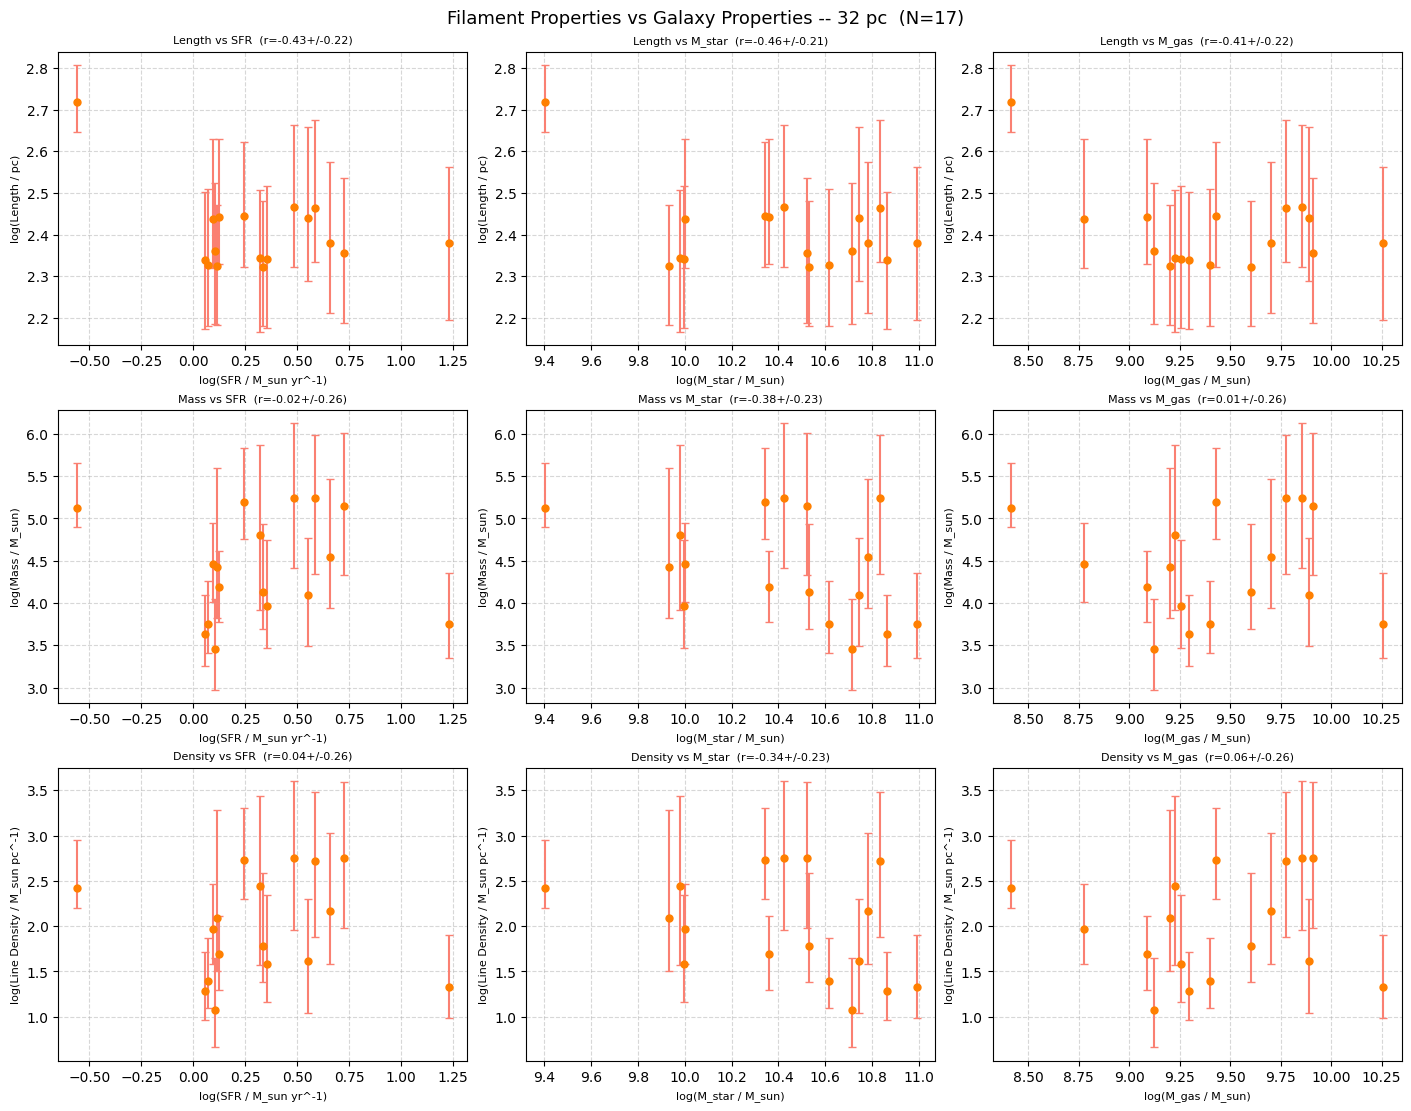

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\Correlations_32pc.png


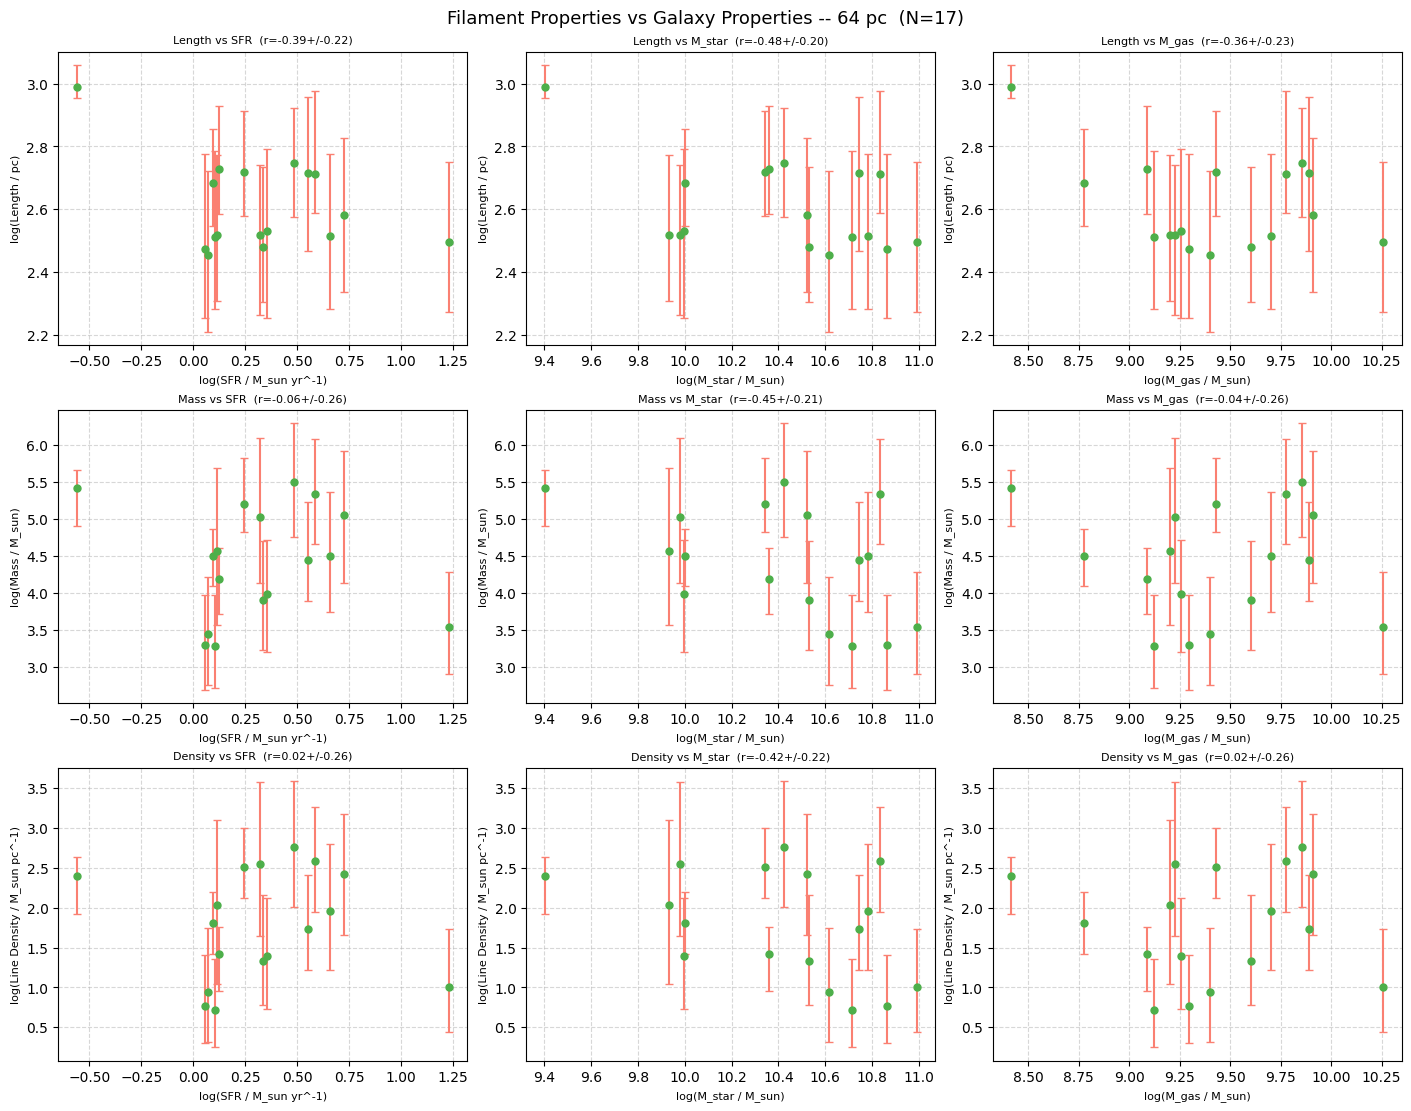

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\Correlations_64pc.png


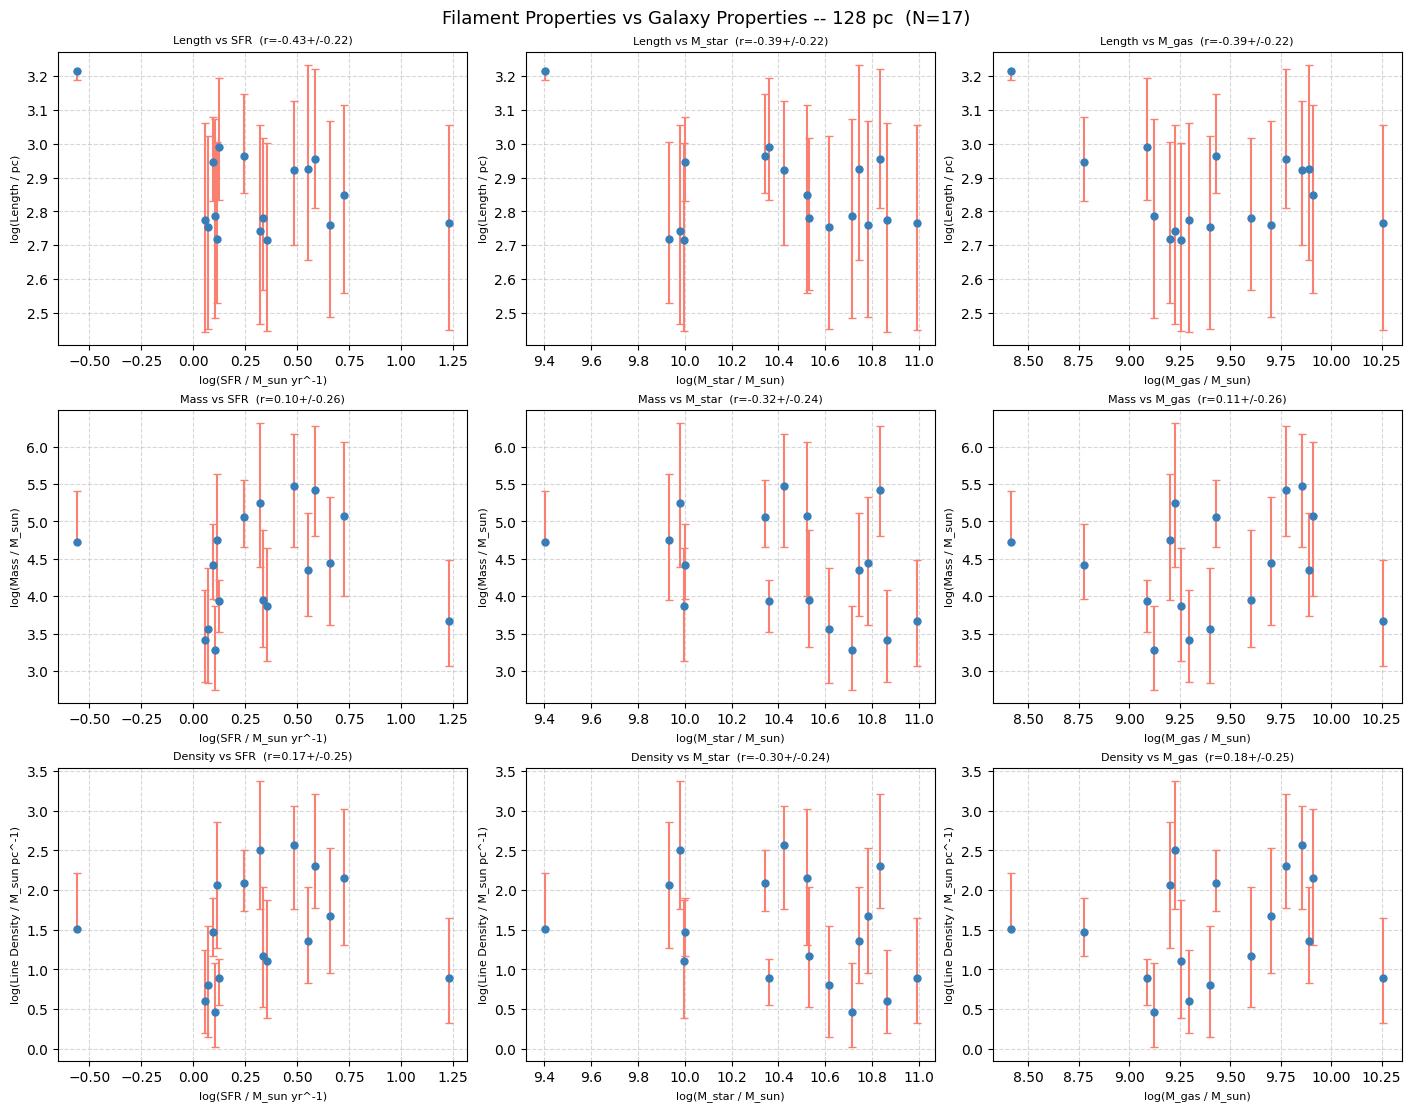

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\Correlations_128pc.png


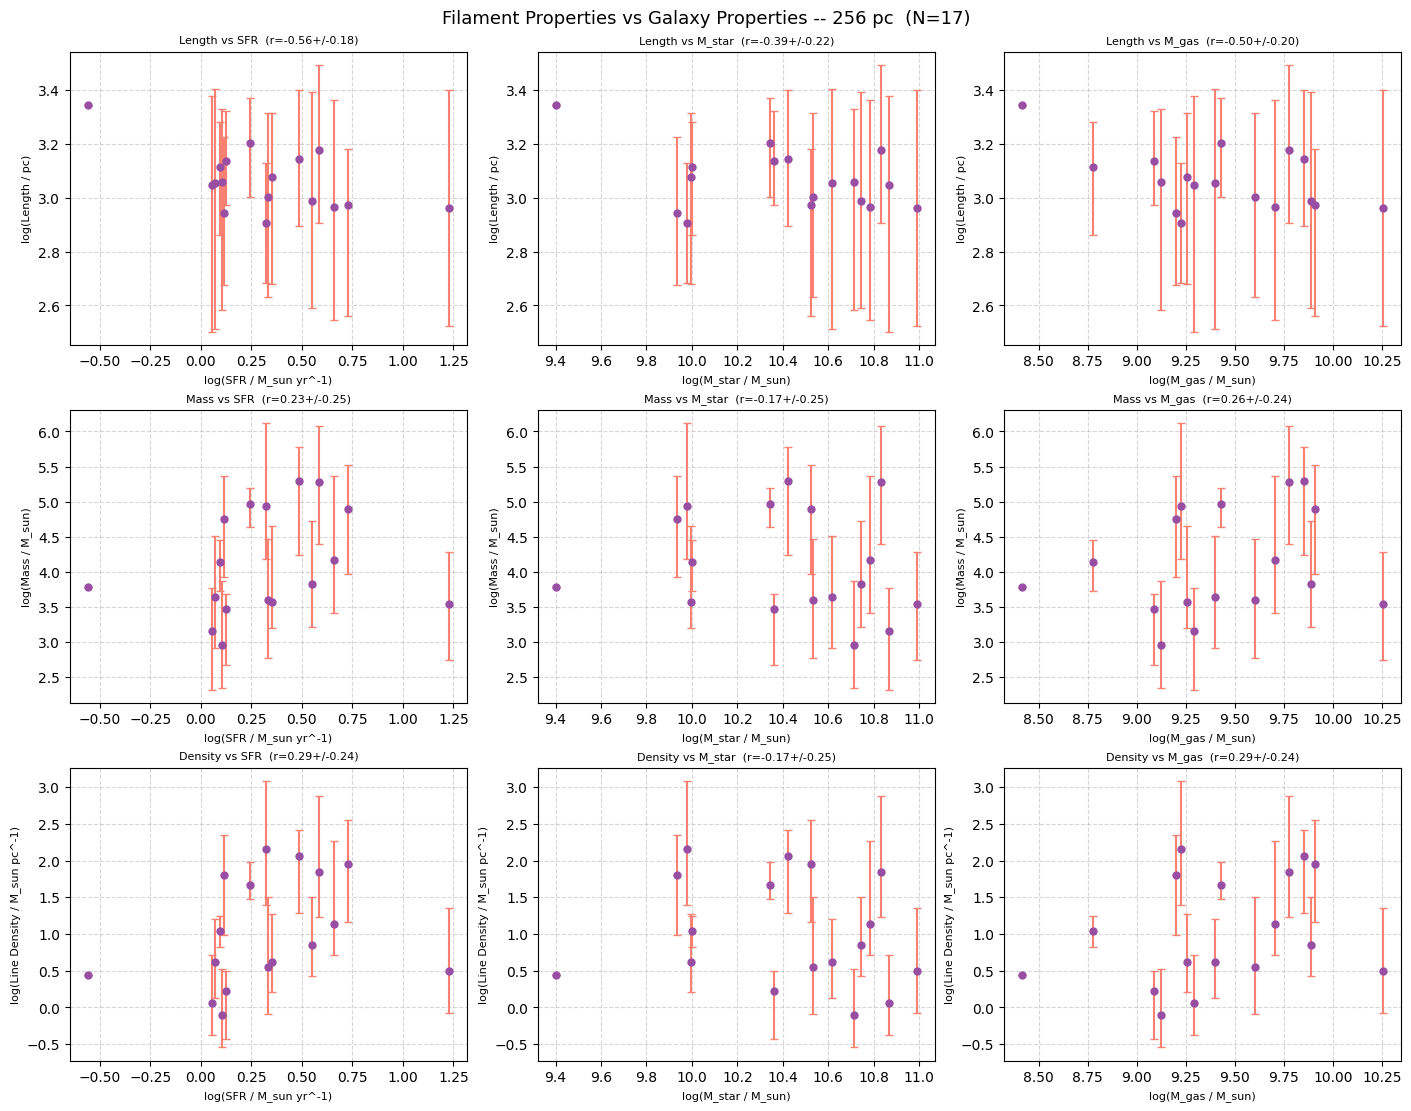

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\Correlations_256pc.png


In [16]:
# =============================================================================
# Cell 4: Filament Properties vs Galaxy Properties -- Correlation Grids
# For each CDD scale, plots filament Length / Mass / Line Density against
# host-galaxy SFR, stellar mass, and gas mass in a 3x3 panel grid.
# Pearson r with 1-sigma Fisher-Z uncertainty is annotated on each panel.
# Requires the PHANGS sample table FITS file (phangs_sample_table_v1p6.fits).
# =============================================================================
from astropy.table import Table

PHANGS_TABLE = r"C:\Users\jhoffm72\Downloads\phangs_sample_table_v1p6.fits"

def get_galaxy_props(galaxy_name):
    """Return (log10 SFR, log10 M_star, log10 M_gas) from the PHANGS sample table."""
    base = galaxy_name.split("_")[0]
    with fits.open(PHANGS_TABLE) as h:
        tbl = Table(h[1].data)
    row = tbl[tbl["name"] == base]
    if not len(row): raise ValueError(f"'{base}' not in PHANGS table")
    def sl(v): return np.log10(float(v)) if float(v) > 0 else np.nan
    return sl(row["props_sfr"][0]), sl(row["props_mstar"][0]), sl(row["mh2_phangs"][0])

# Axis label definitions
Y_META = [
    ("Length",  0, "log(Length / pc)"),
    ("Mass",    1, "log(Mass / M_sun)"),
    ("Density", 2, "log(Line Density / M_sun pc^-1)"),
]
X_META = [
    ("SFR",    3, "log(SFR / M_sun yr^-1)"),
    ("M_star", 4, "log(M_star / M_sun)"),
    ("M_gas",  5, "log(M_gas / M_sun)"),
]

# Build per-scale summary: (median, p16, p84) per galaxy per quantity
all_by_scale = {s: {} for s in SCALES}
for gal in valid_galaxies:
    for s in SCALES:
        arr_l = galaxy_data[gal]["length"].get(s)
        if arr_l is None or not len(arr_l): continue
        try:
            props = get_galaxy_props(gal)
            if not all(np.isfinite(props)): continue
            all_by_scale[s][gal] = (
                stats_log(arr_l),
                stats_log(galaxy_data[gal]["mass"].get(s, [])),
                stats_log(galaxy_data[gal]["density"].get(s, [])),
                *props
            )
        except Exception as e:
            print(f"  {gal}@{s}pc: {e}")

# One 3x3 correlation grid per scale
for s in SCALES:
    gdat = all_by_scale[s]
    if len(gdat) < 3: continue   # need at least 3 galaxies for a meaningful plot
    rows = list(gdat.values())
    dot_color = SCALE_COLORS.get(s, "steelblue")

    fig, axes = plt.subplots(3, 3, figsize=(14, 11), constrained_layout=True)
    for i, (yk, yi, ylabel) in enumerate(Y_META):
        y_med = np.array([r[yi][0] for r in rows])
        y_lo  = np.array([r[yi][0] - r[yi][1] for r in rows])
        y_hi  = np.array([r[yi][2] - r[yi][0] for r in rows])
        for j, (xk, xi, xlabel) in enumerate(X_META):
            ax = axes[i, j]
            xv = np.array([r[xi] for r in rows])
            m  = np.isfinite(xv) & np.isfinite(y_med)
            ax.errorbar(xv[m], y_med[m], yerr=[y_lo[m], y_hi[m]],
                        fmt="o", color=dot_color, ecolor="salmon", capsize=3, ms=5)
            r, re = pearson_with_err(xv[m], y_med[m])
            lbl   = f"r={r:.2f}+/-{re:.2f}" if np.isfinite(r) else "r=N/A"
            ax.set_title(f"{yk} vs {xk}  ({lbl})", fontsize=8)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.grid(True, ls="--", alpha=0.5)

    fig.suptitle(f"Filament Properties vs Galaxy Properties -- {s} pc  (N={len(rows)})",
                 fontsize=13)
    out = OUTPUT_DIR / f"Correlations_{s}pc"
    for ext in (".png", ".pdf"):
        fig.savefig(str(out) + ext, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Saved {out}.png")


  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\MassSFR_AllScales.png


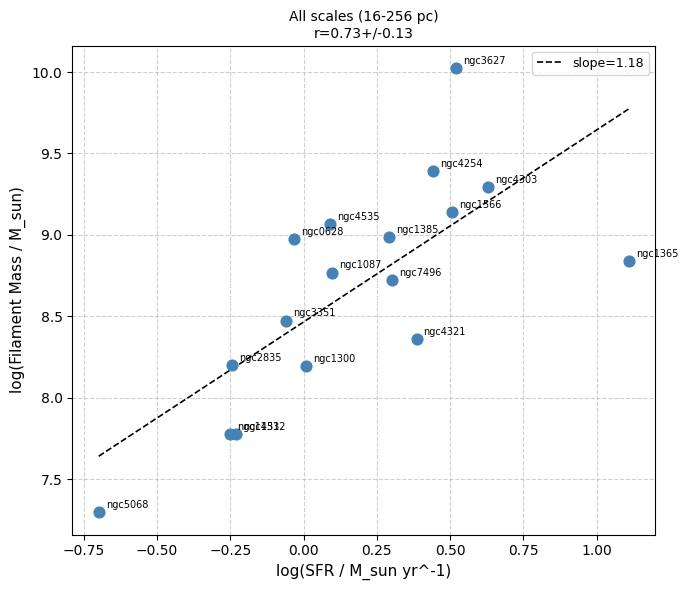

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\MassSFR_SmallScales.png


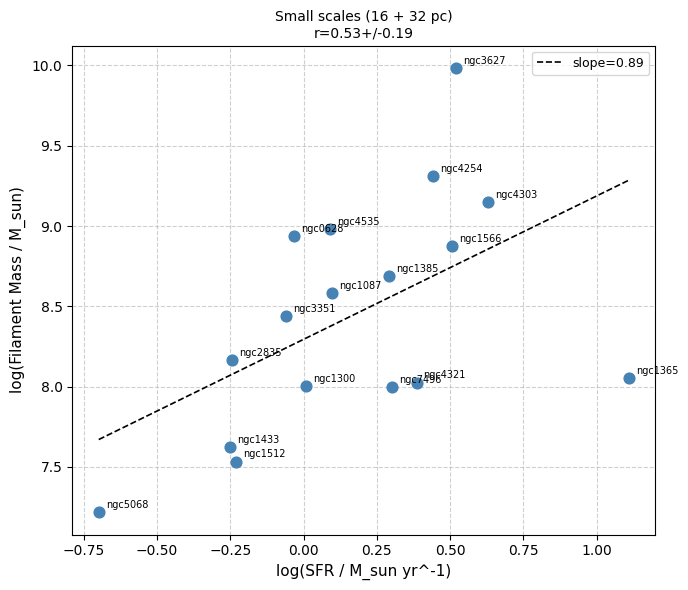

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\MassSFR_IntermediateScales.png


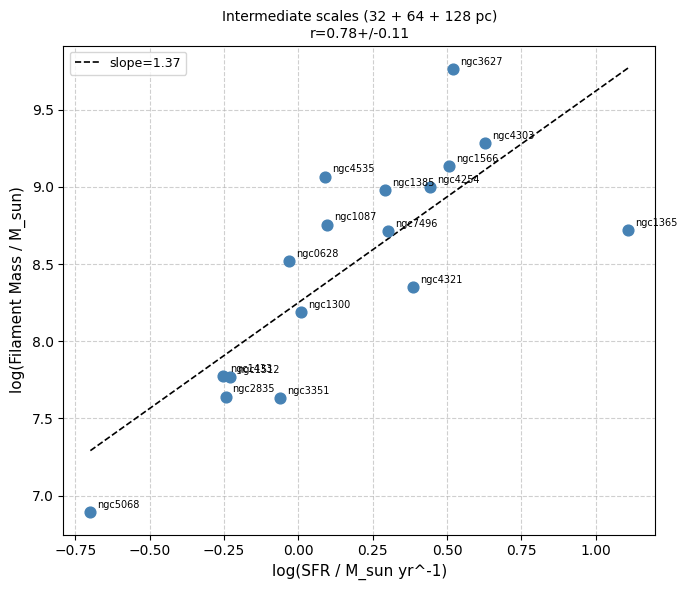

Done. Outputs saved to: C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures


In [17]:
# =============================================================================
# Cell 5: Total Filament Mass vs SFR
# Scatter plot of total filament mass (summed over selected scale combinations)
# against log SFR (Chandar et al. 2025, Table 1 -- see SFR_TABLE in Cell 1).
# Each scale grouping is saved as its own figure.
# =============================================================================

def mass_sfr_scatter(scale_groups, title="", save_name=None):
    """
    Scatter total filament mass vs log SFR for all valid galaxies.
    scale_groups: list of scale strings to sum, e.g. ["16","32"].
    Fits a linear trend and annotates Pearson r.
    Each call produces and saves a standalone figure.
    """
    xs, ys, labels = [], [], []
    for gal in valid_galaxies:
        total = sum(np.nansum(galaxy_data[gal]["mass"].get(s, np.array([])))
                    for s in scale_groups)
        if total <= 0: continue
        try:
            xs.append(get_sfr(gal))
            ys.append(np.log10(total))
            labels.append(gal.replace("_F770W", ""))
        except KeyError:
            continue

    xs, ys = np.array(xs), np.array(ys)
    m = np.isfinite(xs) & np.isfinite(ys)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(xs[m], ys[m], s=60, zorder=3, color="steelblue")
    for x, y, lbl in zip(xs[m], ys[m], [labels[i] for i in np.where(m)[0]]):
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(5, 3), fontsize=7)

    plot_title = title
    if m.sum() >= 3:
        c  = np.polyfit(xs[m], ys[m], 1)
        xf = np.linspace(xs[m].min(), xs[m].max(), 100)
        r, re = pearson_with_err(xs[m], ys[m])
        ax.plot(xf, np.polyval(c, xf), "k--", lw=1.2, label=f"slope={c[0]:.2f}")
        plot_title += f"\nr={r:.2f}+/-{re:.2f}"
        ax.legend(fontsize=9)

    ax.set_xlabel("log(SFR / M_sun yr^-1)", fontsize=11)
    ax.set_ylabel("log(Filament Mass / M_sun)", fontsize=11)
    ax.set_title(plot_title, fontsize=10)
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()

    if save_name:
        for ext in (".png", ".pdf"):
            fig.savefig(OUTPUT_DIR / (Path(save_name).stem + ext), dpi=300, bbox_inches="tight")
        print(f"  Saved {OUTPUT_DIR / save_name}")
    plt.show()
    plt.close(fig)


mass_sfr_scatter(["16","32","64","128","256"],
                 title="All scales (16-256 pc)",
                 save_name="MassSFR_AllScales.png")

mass_sfr_scatter(["16","32"],
                 title="Small scales (16 + 32 pc)",
                 save_name="MassSFR_SmallScales.png")

mass_sfr_scatter(["32","64","128"],
                 title="Intermediate scales (32 + 64 + 128 pc)",
                 save_name="MassSFR_IntermediateScales.png")

print("Done. Outputs saved to:", OUTPUT_DIR)


  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_AllScales.png


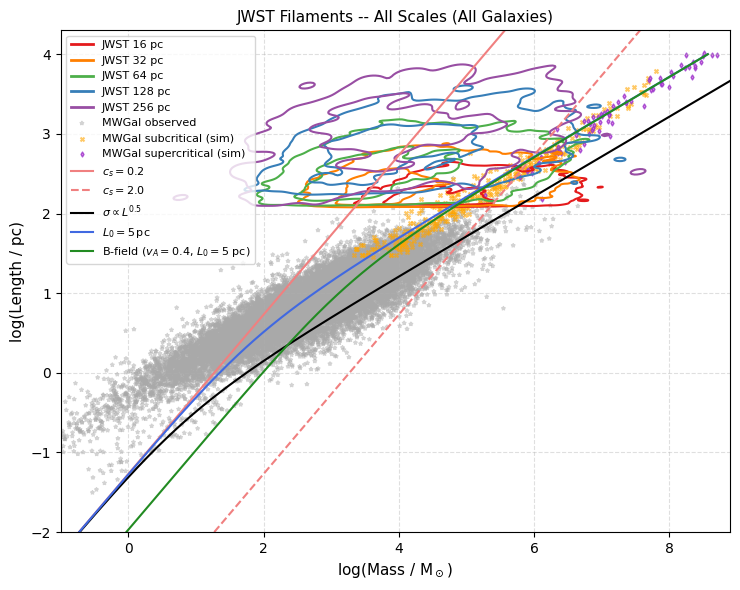

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_16pc.png


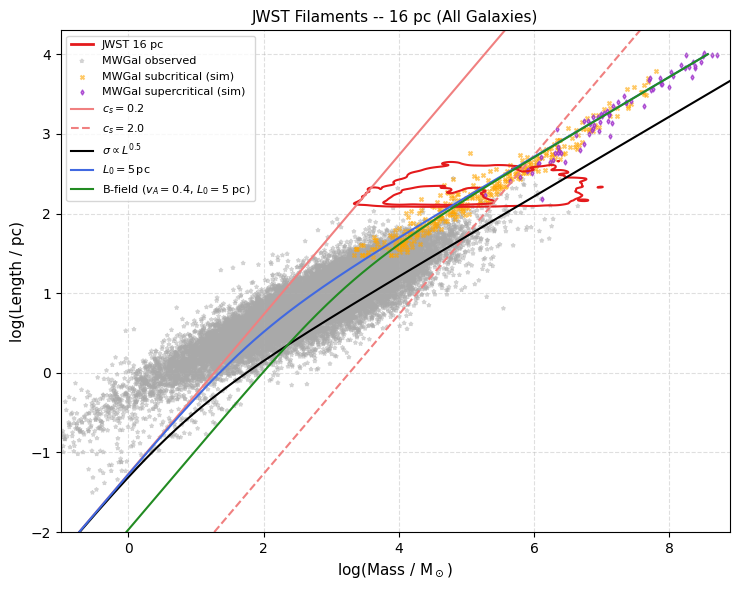

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_32pc.png


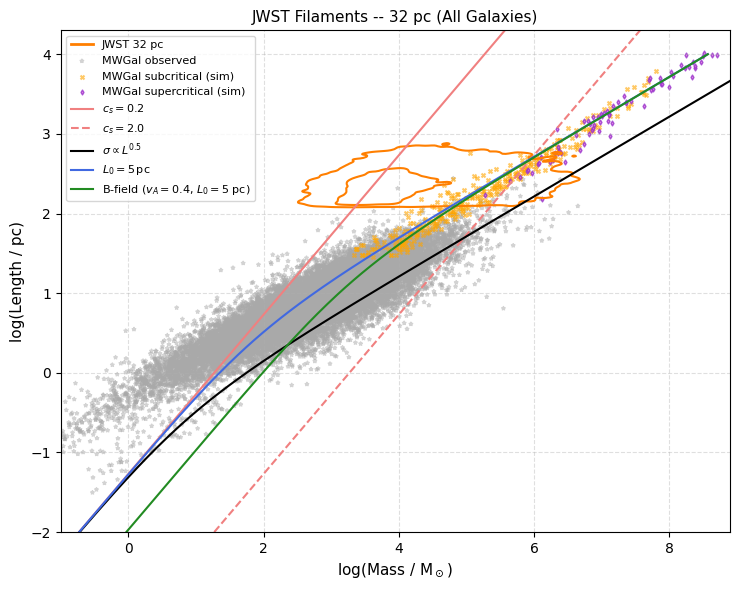

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_64pc.png


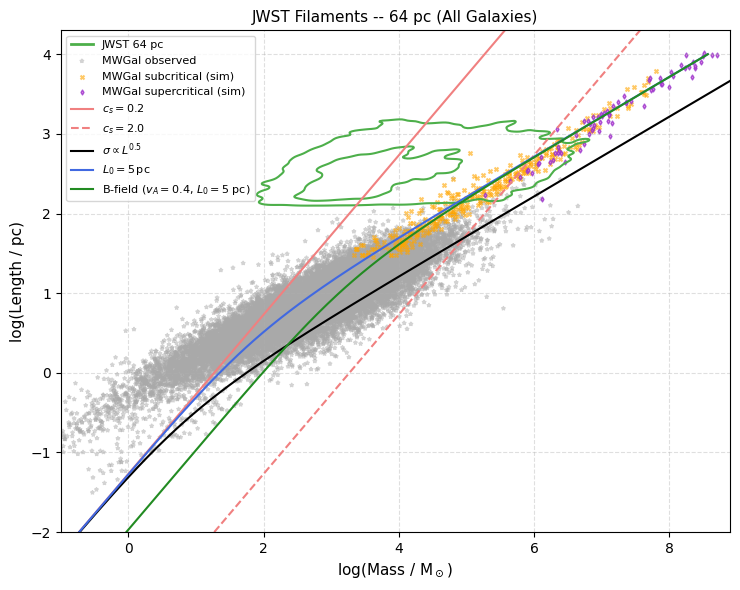

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_128pc.png


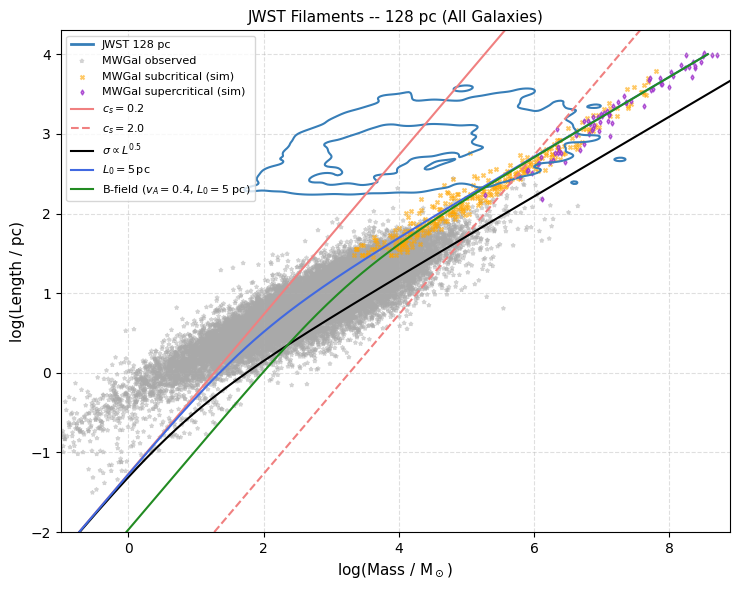

  Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\HacarPlot_All_Galaxies_256pc.png


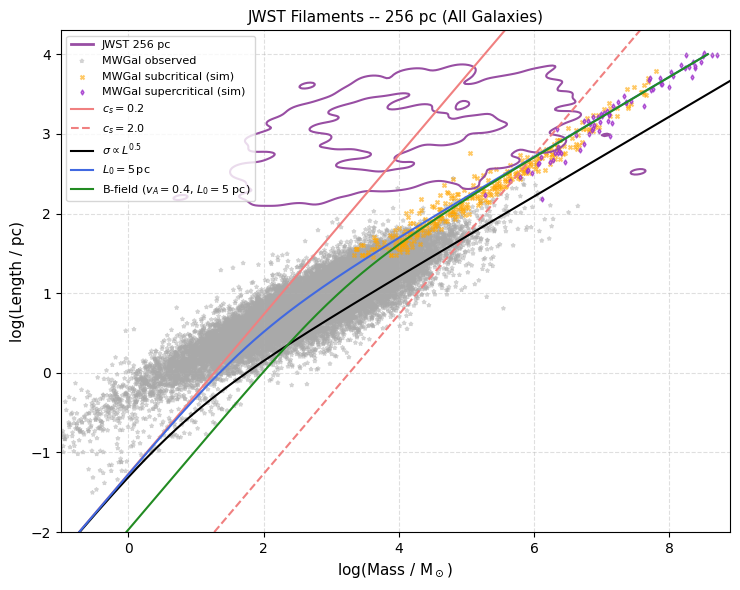

Done.


In [18]:
# =============================================================================
# Cell 6: JWST Filament Mass-Length vs Theory & Reference Observations
# JWST data per scale shown as 2D KDE contour lines.
# Toggle GALAXY_FILTER: None = pool all galaxies; set to e.g. "ngc0628_F770W".
# Depends on Cell 2 (galaxy_data / valid_galaxies) and Cell 3 (master).
# =============================================================================
import matplotlib.cm as cm_module
import seaborn as sns

# -- Edit here ----------------------------------------------------------------
GALAXY_FILTER = None          # None = all galaxies, or e.g. "ngc0628_F770W"
# -----------------------------------------------------------------------------

if GALAXY_FILTER is None:
    _source       = master
    _source_label = "All Galaxies"
elif GALAXY_FILTER in galaxy_data:
    _source       = galaxy_data[GALAXY_FILTER]
    _source_label = GALAXY_FILTER.replace("_F770W", "").upper()
else:
    print(f"'{GALAXY_FILTER}' not found. Available: {valid_galaxies}")
    _source = None

# ---------------------------------------------------------------------------
# Physics helpers (mirrors hacarplot.py)
# ---------------------------------------------------------------------------
def _thermal(cs, M):
    return np.log10((10**M) * 1.989e33 * 6.67e-8 / (2 * (cs * 1e5)**2) / 3.086e18)

def _lscale(cs, L, L0):
    l = (10**L) * 3.086e18
    return np.log10(((2 * (cs*1e5)**2) / 6.67e-8) * l * (1 + (10**L) / L0) / 1.989e33)

def _fBcorr(cs, va, L, L0):
    l = (10**L) * 3.086e18
    return np.log10(((2*(cs*1e5)**2) / 6.67e-8) * l
                    * (1 + (10**L)/L0 + (va/cs)**2) / 1.989e33)

_M = np.linspace(-1, 9.0, 200)
_L = np.linspace(-2, 4, 200)

# ---------------------------------------------------------------------------
# Load reference data
# ---------------------------------------------------------------------------
def _find_csv(name):
    for p in [BASE_DIR / name, Path(".") / name]:
        if p.exists():
            return p
    raise FileNotFoundError(f"'{name}' not found near BASE_DIR or cwd")

try:
    _molFils = pd.read_csv(_find_csv("Fils_obsdata_public.csv"))
    _molFils.sort_values("REF", inplace=True)
    _molFils.set_index("REF", drop=False, inplace=True)
    _mol_ok = True
except Exception as e:
    print(f"WARNING: Fils_obsdata_public.csv: {e}"); _mol_ok = False

try:
    _simdata    = pd.read_csv(_find_csv("simfils_p12025.csv"))
    _ratio      = _simdata["Line Mass"] / _simdata["Magnetic"]
    _super_fil  = _simdata[_ratio >= 1.0]
    _sub        = _simdata[_ratio <  1.0]
    _sim_ok     = True
except Exception as e:
    print(f"WARNING: simfils_p12025.csv: {e}"); _sim_ok = False

# ---------------------------------------------------------------------------
# Uses SCALE_COLORS from Cell 1 -- single source of truth for the palette
# ---------------------------------------------------------------------------
_all_scales = sorted(_source["mass"], key=float) if _source else []
_linestyles = ["solid", "dashed", "dotted", "dashdot", (0, (3, 5, 1, 5, 1, 5))]

def _make_hacar_plot(scales_to_plot, title="", save_name=None):
    if _source is None:
        return
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # JWST filaments -- 2D KDE contour lines per scale
    legend_handles = []
    for i, scale in enumerate(scales_to_plot):
        m = np.array(_source["mass"].get(scale, []))
        l = np.array(_source["length"].get(scale, []))
        mask = (m > 0) & (l > 0)
        lm, ll = np.log10(m[mask]), np.log10(l[mask])
        color = SCALE_COLORS.get(scale, "#333333")

        if len(lm) >= 10:
            try:
                sns.kdeplot(x=lm, y=ll, ax=ax, color=color,
                            levels=3, fill=False, linewidths=1.5,
                            bw_adjust=0.5)
            except Exception as e:
                print(f"  KDE failed for {scale}pc ({len(lm)} pts): {e}")
        else:
            # too few points for KDE -- fall back to scatter
            ax.scatter(lm, ll, s=15, color=color, alpha=0.7, zorder=10)

        from matplotlib.lines import Line2D
        legend_handles.append(Line2D([0], [0], color=color, lw=2,
                                     label=f"JWST {scale} pc"))

    # MWGal observed filaments (keep as scatter -- reference points)
    if _mol_ok and {"Mass_Msun", "L_pc"}.issubset(_molFils.columns):
        _mm = (_molFils["Mass_Msun"] > 0) & (_molFils["L_pc"] > 0)
        ax.scatter(np.log10(_molFils.loc[_mm, "Mass_Msun"]),
                   np.log10(_molFils.loc[_mm, "L_pc"]),
                   s=7, marker="*", facecolors="none", edgecolors="darkgray",
                   alpha=0.5, label="MWGal observed")

    # Simulated filaments (keep as scatter)
    if _sim_ok:
        if not _sub.empty:
            ax.scatter(_sub["log Mass"], _sub["log Length"],
                       s=8, marker="x", color="orange", alpha=0.6,
                       label="MWGal subcritical (sim)")
        if not _super_fil.empty:
            ax.scatter(_super_fil["log Mass"], _super_fil["log Length"],
                       s=6, marker="d", color="orchid", edgecolors="darkorchid",
                       alpha=0.8, label="MWGal supercritical (sim)")

    # Theory lines
    ax.plot(_M, _thermal(0.2, _M), c="lightcoral", linestyle=_linestyles[0], label=r"$c_s = 0.2$")
    ax.plot(_M, _thermal(2.0, _M), c="lightcoral", linestyle=_linestyles[1], label=r"$c_s = 2.0$")
    ax.plot(_lscale(0.2, _L, 0.5), _L, c="black",     linestyle="solid", label=r"$\sigma \propto L^{0.5}$")
    ax.plot(_lscale(0.2, _L, 5.0), _L, c="royalblue", linestyle="solid", label=r"$L_0 = 5\,\mathrm{pc}$")
    ax.plot(_fBcorr(0.2, 0.4, _L, 5.0), _L, c="forestgreen", linestyle="solid",
            label=r"B-field ($v_A=0.4$, $L_0=5$ pc)")

    ax.set_xlabel(r"log(Mass / M$_\odot$)", fontsize=11)
    ax.set_ylabel("log(Length / pc)", fontsize=11)
    ax.set_xlim(-1, 8.9)
    ax.set_ylim(-2, 4.3)

    # Combine JWST contour handles with the rest of the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=legend_handles + handles, fontsize=8, loc="upper left")
    ax.set_title(title, fontsize=11)
    ax.grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    if save_name:
        out = OUTPUT_DIR / save_name
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print(f"  Saved {out}")
    plt.show()
    plt.close(fig)

# ---------------------------------------------------------------------------
# Generate figures
# ---------------------------------------------------------------------------
_tag = _source_label.replace(" ", "_")

_make_hacar_plot(_all_scales,
                 title=f"JWST Filaments -- All Scales ({_source_label})",
                 save_name=f"HacarPlot_{_tag}_AllScales.png")

for _s in _all_scales:
    _make_hacar_plot([_s],
                     title=f"JWST Filaments -- {_s} pc ({_source_label})",
                     save_name=f"HacarPlot_{_tag}_{_s}pc.png")

print("Done.")
